# CodeAlpha Machine Learning Internship — Task 1
## Credit Scoring Model

### Objective
Predict an individual's creditworthiness using historical financial data.

### Dataset
German Credit Dataset

### Models Used
- Logistic Regression
- Random Forest
- Tuned Random Forest

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
data = pd.read_csv('/content/german.data', sep=' ', header=None)

data.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
data.shape

(1000, 21)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1000 non-null   object
 1   1       1000 non-null   int64 
 2   2       1000 non-null   object
 3   3       1000 non-null   object
 4   4       1000 non-null   int64 
 5   5       1000 non-null   object
 6   6       1000 non-null   object
 7   7       1000 non-null   int64 
 8   8       1000 non-null   object
 9   9       1000 non-null   object
 10  10      1000 non-null   int64 
 11  11      1000 non-null   object
 12  12      1000 non-null   int64 
 13  13      1000 non-null   object
 14  14      1000 non-null   object
 15  15      1000 non-null   int64 
 16  16      1000 non-null   object
 17  17      1000 non-null   int64 
 18  18      1000 non-null   object
 19  19      1000 non-null   object
 20  20      1000 non-null   int64 
dtypes: int64(8), object(13)
memory usage: 164.2+ KB


In [6]:
columns = [
    'checking_account', 'duration', 'credit_history',
    'purpose', 'credit_amount', 'savings_account',
    'employment', 'installment_rate', 'personal_status_sex',
    'other_debtors', 'residence_since', 'property',
    'age', 'other_installment_plans', 'housing',
    'existing_credits', 'job', 'dependents',
    'telephone', 'foreign_worker', 'credit_risk'
]

data.columns = columns

data.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [7]:
data.isnull().sum()

,0
checking_account,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_account,0
employment,0
installment_rate,0
personal_status_sex,0
other_debtors,0


In [8]:
data['credit_risk'].value_counts()

,count
credit_risk,
1,700
2,300


In [17]:
data = pd.read_csv('/content/german.data', sep=' ', header=None)

data.columns = columns

data['credit_risk'] = data['credit_risk'].map({
    1: 1,
    2: 0
})

data['credit_risk'].value_counts()

,count
credit_risk,
1,700
0,300


In [18]:
X = data.drop('credit_risk', axis=1)
y = data['credit_risk']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 20)
y shape: (1000,)


Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 20)
Testing data: (200, 20)


In [20]:
X = pd.get_dummies(X, drop_first=True)

print("New X shape:", X.shape)

New X shape: (1000, 48)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 48)
Testing data: (200, 48)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Training data: (800, 48)
Testing data: (200, 48)


Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [24]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed!")
print("First 10 predictions:", y_pred[:10])

Predictions completed!
First 10 predictions: [1 0 0 1 0 1 1 1 0 1]


In [25]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.47      0.49        60
           1       0.78      0.81      0.80       140

    accuracy                           0.71       200
   macro avg       0.65      0.64      0.64       200
weighted avg       0.70      0.71      0.71       200



Training Random Forest Model

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.72


In [27]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.33      0.42        60
           1       0.76      0.89      0.82       140

    accuracy                           0.72       200
   macro avg       0.66      0.61      0.62       200
weighted avg       0.70      0.72      0.70       200



In [28]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", roc_auc)

Random Forest ROC-AUC: 0.765


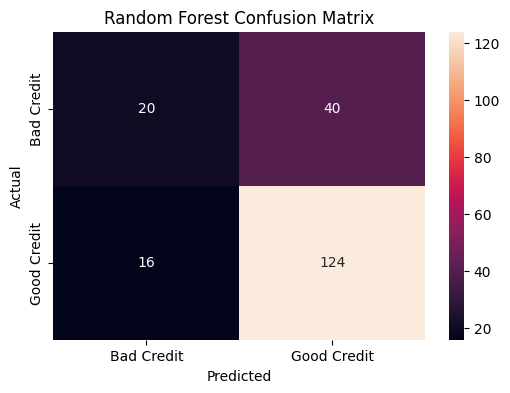

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Bad Credit', 'Good Credit'],
    yticklabels=['Bad Credit', 'Good Credit']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [30]:
print("Model Comparison")
print("-----------------------------")
print("Logistic Regression:", accuracy)
print("Random Forest:", rf_accuracy)

Model Comparison
-----------------------------
Logistic Regression: 0.71
Random Forest: 0.72


In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation F1: 0.8351165044330985


In [32]:
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, best_rf_pred))

Tuned Random Forest Accuracy: 0.72


In [33]:
from sklearn.metrics import classification_report

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_rf_pred))

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.33      0.42        60
           1       0.76      0.89      0.82       140

    accuracy                           0.72       200
   macro avg       0.66      0.61      0.62       200
weighted avg       0.70      0.72      0.70       200



In [34]:
from sklearn.metrics import roc_auc_score

best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

best_rf_roc_auc = roc_auc_score(y_test, best_rf_prob)

print("Tuned Random Forest ROC-AUC:", best_rf_roc_auc)

Tuned Random Forest ROC-AUC: 0.765


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression probabilities
lr_prob = model.predict_proba(X_test_scaled)[:, 1]

# Tuned Random Forest probabilities
rf_prob = best_rf.predict_proba(X_test)[:, 1]

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, best_rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, best_rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, best_rf_pred)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, best_rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.71,0.780822,0.814286,0.797203,0.753095
1,Tuned Random Forest,0.72,0.756098,0.885714,0.815789,0.765000


In [38]:
final_model = best_rf

print("Final Model: Tuned Random Forest")
print("Test Accuracy:", accuracy_score(y_test, best_rf_pred))
print("Test F1-Score:", f1_score(y_test, best_rf_pred))
print("Test ROC-AUC:", best_rf_roc_auc)

Final Model: Tuned Random Forest
Test Accuracy: 0.72
Test F1-Score: 0.8157894736842105
Test ROC-AUC: 0.765


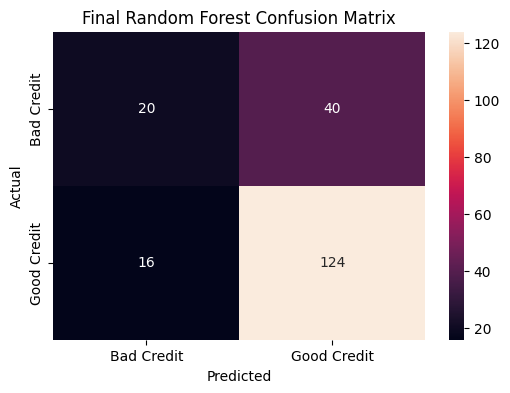

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

final_cm = confusion_matrix(y_test, best_rf_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    xticklabels=['Bad Credit', 'Good Credit'],
    yticklabels=['Bad Credit', 'Good Credit']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Random Forest Confusion Matrix")

plt.show()

Feature Importance

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
                         Feature  Importance
1                  credit_amount    0.108553
4                            age    0.089327
9           checking_account_A14    0.088274
0                       duration    0.087819
2               installment_rate    0.038552
3                residence_since    0.036718
13            credit_history_A34    0.027199
40  other_installment_plans_A143    0.023755
17                   purpose_A43    0.021447
14                   purpose_A41    0.021428


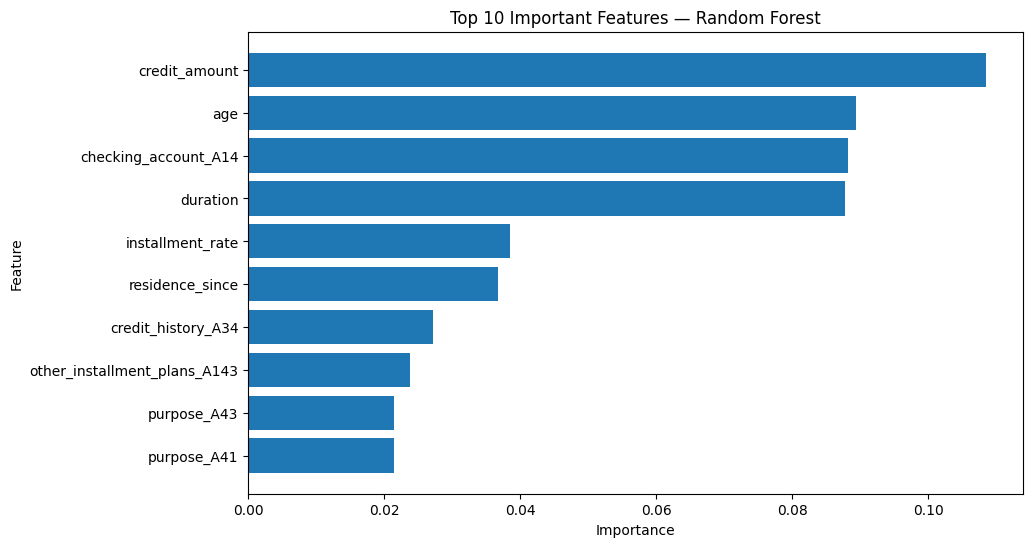

In [41]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance.head(10)["Feature"],
    feature_importance.head(10)["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features — Random Forest")

plt.gca().invert_yaxis()
plt.show()

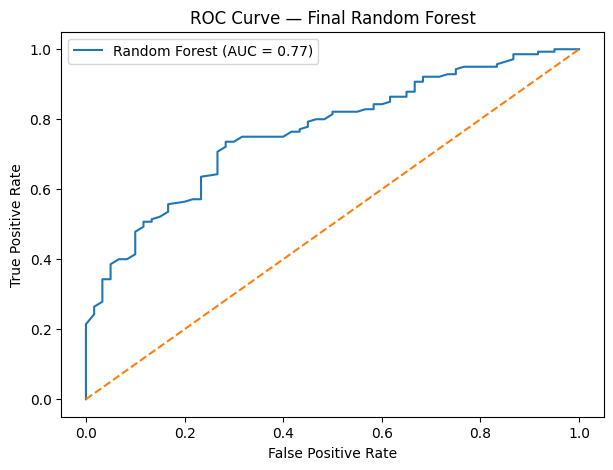

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Random Forest")
plt.legend()

plt.show()

In [43]:
import joblib

joblib.dump(final_model, "credit_scoring_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [44]:
import joblib

# Save the feature columns used during training
joblib.dump(X.columns.tolist(), "credit_scoring_features.pkl")

print("Preprocessing information saved successfully!")

Preprocessing information saved successfully!


In [46]:
print("===== CREDIT SCORING MODEL =====")
print()
print("Logistic Regression Accuracy:", round(accuracy, 2))
print("Random Forest Accuracy:", round(rf_accuracy, 2))
print("Final Model Accuracy:", round(accuracy_score(y_test, best_rf_pred), 2))
print("Final Model F1-Score:", round(f1_score(y_test, best_rf_pred), 2))
print("Final Model ROC-AUC:", round(best_rf_roc_auc, 2))
print()
print("Final Model: Tuned Random Forest")

===== CREDIT SCORING MODEL =====

Logistic Regression Accuracy: 0.71
Random Forest Accuracy: 0.72
Final Model Accuracy: 0.72
Final Model F1-Score: 0.82
Final Model ROC-AUC: 0.76

Final Model: Tuned Random Forest
